# 03 Dataset Quantity and Episode 1 Feature Extraction

Notebook ini menjawab dua pertanyaan: berapa banyak defensive transition yang tersedia pada tujuh pertandingan IDSSE, dan apakah satu episode quick regain dapat menghasilkan fitur respons pemain yang konsisten.

Metodologi yang dipertahankan:
- candidate adalah perubahan `ball_owning_team_id` saat bola aktif;
- quick regain bernilai 1 jika losing team kembali menguasai bola pada perubahan possession pertama yang sesuai dalam lima detik;
- Episode 1 adalah positive candidate pertama setelah data diurutkan berdasarkan match, period, dan waktu;
- feature extraction memakai fase `T0 loss` sampai `T1 regain` dan 11 pemain losing team yang valid pada frame loss.

Implementasi regain percobaan yang hanya memeriksa candidate berikutnya dihapus. Notebook memakai versi terkoreksi yang mencari seluruh candidate dalam horizon lima detik. Jarak pemain-bola tetap dihitung dari koordinat ternormalisasi IDSSE, sehingga satuannya adalah normalized pitch unit, bukan meter.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.idsse_episode_dataset import (
    build_player_team_map,
    detect_turnover_candidates,
    load_match,
)

DATA_DIR = PROJECT_ROOT / 'data' / 'sportec_idsse'
MATCH_IDS = [
    'J03WPY', 'J03WMX', 'J03WN1', 'J03WOH',
    'J03WOY', 'J03WQQ', 'J03WR9',
]
REGAIN_HORIZON_SECONDS = 5.0
print('Data directory:', DATA_DIR)
print('Matches:', len(MATCH_IDS))

Data directory: c:\VAEP-Track\data\sportec_idsse
Matches: 7


In [2]:
match_rows = []
candidate_tables = []

for match_id in MATCH_IDS:
    tracking, events = load_match(DATA_DIR, match_id)
    previous_owner = tracking.groupby('period_id')[
        'ball_owning_team_id'
    ].shift(1)
    all_change_mask = (
        tracking['ball_owning_team_id'].notna()
        & previous_owner.notna()
        & tracking['ball_owning_team_id'].ne(previous_owner)
    )
    candidates = detect_turnover_candidates(
        tracking,
        match_id,
        regain_horizon_seconds=REGAIN_HORIZON_SECONDS,
    )
    candidate_tables.append(candidates)
    match_rows.append({
        'match_id': match_id,
        'tracking_frames': len(tracking),
        'owning_team_valid_frames': int(
            tracking['ball_owning_team_id'].notna().sum()
        ),
        'all_possession_changes': int(all_change_mask.sum()),
        'active_possession_changes': len(candidates),
        'quick_regain_5s': int(candidates['label_regain_5s'].sum()),
    })
    print(
        f"{match_id}: candidates={len(candidates)}, "
        f"quick_regain={int(candidates['label_regain_5s'].sum())}"
    )

summary_df = pd.DataFrame(match_rows)
all_candidates_df = (
    pd.concat(candidate_tables, ignore_index=True)
    .sort_values(['match_id', 'period_id', 'loss_timestamp', 'loss_frame'])
    .reset_index(drop=True)
)
display(summary_df)
display(summary_df.drop(columns='match_id').sum().rename('TOTAL').to_frame())

J03WPY: candidates=324, quick_regain=148
J03WMX: candidates=408, quick_regain=211
J03WN1: candidates=394, quick_regain=204
J03WOH: candidates=301, quick_regain=138
J03WOY: candidates=344, quick_regain=171
J03WQQ: candidates=304, quick_regain=121
J03WR9: candidates=278, quick_regain=112


,match_id,tracking_frames,owning_team_valid_frames,all_possession_changes,active_possession_changes,quick_regain_5s
0,J03WPY,146211,146211,390,324,148
1,J03WMX,145967,145967,500,408,211
2,J03WN1,141561,141561,467,394,204
3,J03WOH,137214,137214,366,301,138
4,J03WOY,142536,142536,416,344,171
5,J03WQQ,142345,142345,362,304,121
6,J03WR9,146810,146810,346,278,112


,TOTAL
tracking_frames,1002644
owning_team_valid_frames,1002644
all_possession_changes,2847
active_possession_changes,2353
quick_regain_5s,1105


In [3]:
changes_time = all_candidates_df.copy()
changes_time['previous_change_timestamp'] = changes_time.groupby(
    ['match_id', 'period_id']
)['loss_timestamp'].shift(1)
changes_time['gap_seconds'] = (
    changes_time['loss_timestamp']
    - changes_time['previous_change_timestamp']
).dt.total_seconds()
gap_stats = changes_time['gap_seconds'].dropna()

regain_distribution = all_candidates_df.groupby('match_id').agg(
    candidates=('candidate_id', 'size'),
    quick_regain_5s=('label_regain_5s', 'sum'),
)
regain_distribution['non_regain_5s'] = (
    regain_distribution['candidates']
    - regain_distribution['quick_regain_5s']
)
regain_distribution['quick_regain_percent'] = (
    regain_distribution['quick_regain_5s']
    / regain_distribution['candidates'] * 100
).round(2)

print('Inter-change gap statistics (seconds):')
display(gap_stats.describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
).to_frame('value'))
display(pd.Series({
    'gap_le_0.5s': int((gap_stats <= 0.5).sum()),
    'gap_le_1s': int((gap_stats <= 1.0).sum()),
    'gap_le_2s': int((gap_stats <= 2.0).sum()),
    'gap_gt_2s': int((gap_stats > 2.0).sum()),
    'gap_gt_5s': int((gap_stats > 5.0).sum()),
}, name='count').to_frame())
print('Quick-regain distribution:')
display(regain_distribution)
print(
    'Total quick regain <=5s:',
    int(all_candidates_df['label_regain_5s'].sum()),
    f"({all_candidates_df['label_regain_5s'].mean():.2%})",
)
display(all_candidates_df.loc[
    all_candidates_df['label_regain_5s'].eq(1),
    [
        'candidate_id', 'match_id', 'period_id', 'loss_timestamp',
        'losing_team', 'opponent_team', 'regain_timestamp',
        'regain_gap_seconds',
    ],
].head(20))

Inter-change gap statistics (seconds):


,value
count,2339.000000
mean,16.854656
std,25.015458
min,0.040000
25%,2.160000
50%,5.640000
75%,23.220000
90%,47.360000
95%,63.900000
max,266.840000


,count
gap_le_0.5s,91
gap_le_1s,224
gap_le_2s,529
gap_gt_2s,1810
gap_gt_5s,1234


Quick-regain distribution:


,candidates,quick_regain_5s,non_regain_5s,quick_regain_percent
match_id,,,,
J03WMX,408,211,197,51.72
J03WN1,394,204,190,51.78
J03WOH,301,138,163,45.85
J03WOY,344,171,173,49.71
J03WPY,324,148,176,45.68
J03WQQ,304,121,183,39.80
J03WR9,278,112,166,40.29


Total quick regain <=5s: 1105 (46.96%)


,candidate_id,match_id,period_id,loss_timestamp,losing_team,opponent_team,regain_timestamp,regain_gap_seconds
3,J03WMX_P1_F12051,J03WMX,1,0 days 00:01:22.040000,DFL-CLU-00000G,DFL-CLU-000008,0 days 00:01:25.320000,3.28
6,J03WMX_P1_F13244,J03WMX,1,0 days 00:02:09.760000,DFL-CLU-00000G,DFL-CLU-000008,0 days 00:02:14.680000,4.92
8,J03WMX_P1_F13589,J03WMX,1,0 days 00:02:23.560000,DFL-CLU-00000G,DFL-CLU-000008,0 days 00:02:25.160000,1.60
9,J03WMX_P1_F13629,J03WMX,1,0 days 00:02:25.160000,DFL-CLU-000008,DFL-CLU-00000G,0 days 00:02:30.040000,4.88
14,J03WMX_P1_F16867,J03WMX,1,0 days 00:04:34.680000,DFL-CLU-00000G,DFL-CLU-000008,0 days 00:04:34.920000,0.24
15,J03WMX_P1_F16873,J03WMX,1,0 days 00:04:34.920000,DFL-CLU-000008,DFL-CLU-00000G,0 days 00:04:36.600000,1.68
18,J03WMX_P1_F17622,J03WMX,1,0 days 00:05:04.880000,DFL-CLU-00000G,DFL-CLU-000008,0 days 00:05:06.040000,1.16
20,J03WMX_P1_F18417,J03WMX,1,0 days 00:05:36.680000,DFL-CLU-00000G,DFL-CLU-000008,0 days 00:05:40.040000,3.36
22,J03WMX_P1_F18817,J03WMX,1,0 days 00:05:52.680000,DFL-CLU-00000G,DFL-CLU-000008,0 days 00:05:53.680000,1.00
24,J03WMX_P1_F19042,J03WMX,1,0 days 00:06:01.680000,DFL-CLU-00000G,DFL-CLU-000008,0 days 00:06:02.240000,0.56


In [4]:
episode = (
    all_candidates_df[all_candidates_df['label_regain_5s'].eq(1)]
    .sort_values(['match_id', 'period_id', 'loss_timestamp', 'loss_frame'])
    .iloc[0]
    .copy()
)
display(pd.Series({
    'candidate_id': episode['candidate_id'],
    'match_id': episode['match_id'],
    'period_id': episode['period_id'],
    'loss_timestamp': episode['loss_timestamp'],
    'regain_timestamp': episode['regain_timestamp'],
    'loss_frame': episode['loss_frame'],
    'regain_frame': episode['regain_frame'],
    'regain_gap_seconds': episode['regain_gap_seconds'],
    'losing_team': episode['losing_team'],
    'opponent_team': episode['opponent_team'],
}, name='Episode 1').to_frame())

episode_tracking, episode_events = load_match(DATA_DIR, episode['match_id'])
period_id = int(episode['period_id'])
t0 = pd.Timedelta(episode['loss_timestamp'])
t1 = pd.Timedelta(episode['regain_timestamp'])
post_loss_window = episode_tracking[
    episode_tracking['period_id'].eq(period_id)
    & episode_tracking['timestamp'].between(t0, t1)
].copy()

player_team_map = build_player_team_map(episode_events)
player_ids_tracking = sorted({
    column[:-2]
    for column in episode_tracking.columns
    if column.startswith('DFL-OBJ-') and column.endswith('_x')
})
loss_row = episode_tracking[
    episode_tracking['period_id'].eq(period_id)
    & episode_tracking['frame_id'].eq(int(episode['loss_frame']))
].iloc[0]
losing_player_ids = [
    player_id
    for player_id in player_ids_tracking
    if player_team_map.get(player_id) == episode['losing_team']
    and pd.notna(loss_row.get(f'{player_id}_x'))
    and pd.notna(loss_row.get(f'{player_id}_y'))
]

records = []
for _, frame in post_loss_window.iterrows():
    ball_x, ball_y = frame['ball_x'], frame['ball_y']
    if pd.isna(ball_x) or pd.isna(ball_y):
        continue
    relative_time = (frame['timestamp'] - t0).total_seconds()
    for player_id in losing_player_ids:
        px, py = frame[f'{player_id}_x'], frame[f'{player_id}_y']
        if pd.isna(px) or pd.isna(py):
            continue
        records.append({
            'timestamp': frame['timestamp'],
            'relative_time': relative_time,
            'frame_id': int(frame['frame_id']),
            'player_id': player_id,
            'distance_to_ball': float(np.hypot(px - ball_x, py - ball_y)),
            'speed': frame.get(f'{player_id}_s', np.nan),
        })

post_loss_ts = (
    pd.DataFrame(records)
    .sort_values(['player_id', 'timestamp'])
    .reset_index(drop=True)
)
post_loss_ts['delta_distance'] = post_loss_ts.groupby(
    'player_id'
)['distance_to_ball'].diff()
post_loss_ts['delta_time'] = post_loss_ts.groupby(
    'player_id'
)['relative_time'].diff()
post_loss_ts['approach_rate'] = (
    -post_loss_ts['delta_distance'] / post_loss_ts['delta_time']
).replace([np.inf, -np.inf], np.nan)

print('Post-loss frames:', len(post_loss_window))
print('Losing-team active players:', len(losing_player_ids))
print('Distance time-series shape:', post_loss_ts.shape)
print('Distance unit: normalized pitch coordinate')
display(post_loss_ts.head())

,Episode 1
candidate_id,J03WMX_P1_F12051
match_id,J03WMX
period_id,1
loss_timestamp,0 days 00:01:22.040000
regain_timestamp,0 days 00:01:25.320000
loss_frame,12051
regain_frame,12133
regain_gap_seconds,3.28
losing_team,DFL-CLU-00000G
opponent_team,DFL-CLU-000008


Post-loss frames: 83
Losing-team active players: 11
Distance time-series shape: (913, 9)
Distance unit: normalized pitch coordinate


,timestamp,relative_time,frame_id,player_id,distance_to_ball,speed,delta_distance,delta_time,approach_rate
0,0 days 00:01:22.040000,0.00,12051,DFL-OBJ-0000IA,0.137564,4.87,NaN,NaN,NaN
1,0 days 00:01:22.080000,0.04,12052,DFL-OBJ-0000IA,0.134784,4.66,-0.002779,0.04,0.069484
2,0 days 00:01:22.120000,0.08,12053,DFL-OBJ-0000IA,0.133891,4.41,-0.000893,0.04,0.022327
3,0 days 00:01:22.160000,0.12,12054,DFL-OBJ-0000IA,0.131816,4.21,-0.002076,0.04,0.051889
4,0 days 00:01:22.200000,0.16,12055,DFL-OBJ-0000IA,0.129476,4.00,-0.002339,0.04,0.058485


In [5]:
feature_base = post_loss_ts.copy()
feature_base['is_approaching_ball'] = feature_base['approach_rate'].gt(0)

player_response = feature_base.groupby('player_id').agg(
    distance_t0=('distance_to_ball', 'first'),
    distance_t1=('distance_to_ball', 'last'),
    min_distance=('distance_to_ball', 'min'),
    speed_t0=('speed', 'first'),
    max_speed=('speed', 'max'),
    max_approach_rate=('approach_rate', 'max'),
    mean_approach_rate=('approach_rate', 'mean'),
).reset_index()
player_response['distance_change'] = (
    player_response['distance_t1'] - player_response['distance_t0']
)
player_response['distance_reduction'] = (
    player_response['distance_t0'] - player_response['min_distance']
)

temporal_features = feature_base.groupby('player_id').agg(
    observed_frames=('frame_id', 'count'),
    mean_speed=('speed', 'mean'),
    speed_t1=('speed', 'last'),
    positive_approach_frames=('is_approaching_ball', 'sum'),
    total_distance_movement=(
        'distance_to_ball', lambda values: values.diff().abs().sum()
    ),
).reset_index()
temporal_features['approach_frame_share'] = (
    temporal_features['positive_approach_frames']
    / temporal_features['observed_frames']
)
min_distance_rows = (
    feature_base.sort_values(
        ['player_id', 'distance_to_ball', 'relative_time']
    )
    .groupby('player_id').head(1)[
        ['player_id', 'relative_time', 'frame_id']
    ]
    .rename(columns={
        'relative_time': 'time_to_min_distance',
        'frame_id': 'min_distance_frame',
    })
)
first_approach_rows = (
    feature_base[feature_base['approach_rate'].gt(0)]
    .sort_values(['player_id', 'relative_time'])
    .groupby('player_id').head(1)[['player_id', 'relative_time']]
    .rename(columns={'relative_time': 'first_approach_time'})
)

episode_player_features = (
    player_response
    .merge(temporal_features, on='player_id', how='left')
    .merge(min_distance_rows, on='player_id', how='left')
    .merge(first_approach_rows, on='player_id', how='left')
)
episode_player_features['distance_reduction_ratio'] = np.where(
    episode_player_features['distance_t0'].gt(0),
    episode_player_features['distance_reduction']
    / episode_player_features['distance_t0'],
    np.nan,
)
episode_player_features['speed_change'] = (
    episode_player_features['speed_t1']
    - episode_player_features['speed_t0']
)
episode_player_features['approached_ball'] = (
    episode_player_features['distance_change'].lt(0)
)
episode_player_features = episode_player_features.sort_values(
    ['distance_reduction', 'max_approach_rate'],
    ascending=[False, False],
).reset_index(drop=True)

closest_t0_idx = episode_player_features['distance_t0'].idxmin()
closest_t1_idx = episode_player_features['distance_t1'].idxmin()
best_response_idx = episode_player_features['distance_reduction'].idxmax()
episode_team_features = pd.DataFrame([{
    'match_id': episode['match_id'],
    'period_id': period_id,
    'loss_frame': int(episode['loss_frame']),
    'regain_frame': int(episode['regain_frame']),
    'regain_gap_seconds': float(episode['regain_gap_seconds']),
    'losing_team': episode['losing_team'],
    'opponent_team': episode['opponent_team'],
    'n_losing_players': len(losing_player_ids),
    'n_players_approached_ball': int(
        episode_player_features['approached_ball'].sum()
    ),
    'mean_distance_t0': episode_player_features['distance_t0'].mean(),
    'mean_distance_t1': episode_player_features['distance_t1'].mean(),
    'mean_distance_reduction': episode_player_features[
        'distance_reduction'
    ].mean(),
    'max_distance_reduction': episode_player_features[
        'distance_reduction'
    ].max(),
    'mean_approach_rate': episode_player_features[
        'mean_approach_rate'
    ].mean(),
    'max_approach_rate': episode_player_features[
        'max_approach_rate'
    ].max(),
    'mean_speed_after_loss': episode_player_features['mean_speed'].mean(),
    'max_speed_after_loss': episode_player_features['max_speed'].max(),
    'closest_player_t0': episode_player_features.loc[
        closest_t0_idx, 'player_id'
    ],
    'closest_player_t1': episode_player_features.loc[
        closest_t1_idx, 'player_id'
    ],
    'best_response_player': episode_player_features.loc[
        best_response_idx, 'player_id'
    ],
}])

numeric_feature_columns = [
    'distance_t0', 'distance_t1', 'min_distance', 'distance_change',
    'distance_reduction', 'distance_reduction_ratio', 'speed_t0',
    'speed_t1', 'speed_change', 'mean_speed', 'max_speed',
    'mean_approach_rate', 'max_approach_rate', 'approach_frame_share',
    'time_to_min_distance', 'first_approach_time',
    'total_distance_movement',
]
episode_feature_matrix = (
    episode_player_features.set_index('player_id')[numeric_feature_columns]
    .astype(float)
)

print('Player feature table shape:', episode_player_features.shape)
print('Episode feature shape     :', episode_team_features.shape)
print('Numeric matrix shape      :', episode_feature_matrix.shape)
display(episode_player_features)
display(episode_team_features)
display(episode_feature_matrix.head())

Player feature table shape: (11, 22)
Episode feature shape     : (1, 20)
Numeric matrix shape      : (11, 17)


,player_id,distance_t0,distance_t1,min_distance,speed_t0,max_speed,max_approach_rate,mean_approach_rate,distance_change,distance_reduction,...,speed_t1,positive_approach_frames,total_distance_movement,approach_frame_share,time_to_min_distance,min_distance_frame,first_approach_time,distance_reduction_ratio,speed_change,approached_ball
0,DFL-OBJ-0027KL,0.175512,0.008537,0.008537,9.15,12.99,0.361337,0.050907,-0.166975,0.166975,...,8.77,51,0.245374,0.614458,3.28,12133,1.16,0.951358,-0.38,True
1,DFL-OBJ-J01APO,0.787650,0.662204,0.661956,8.87,9.79,0.111206,0.038246,-0.125447,0.125694,...,2.36,79,0.132247,0.951807,3.24,12132,0.04,0.159580,-6.51,True
2,DFL-OBJ-0002F5,0.370243,0.282505,0.282083,5.78,10.80,0.125261,0.026749,-0.087737,0.088160,...,5.58,73,0.100687,0.879518,3.24,12132,0.04,0.238115,-0.20,True
3,DFL-OBJ-0002DR,0.506937,0.426528,0.426528,2.81,12.12,0.177953,0.024515,-0.080408,0.080408,...,12.12,45,0.175530,0.542169,3.28,12133,1.52,0.158616,9.31,True
4,DFL-OBJ-J017RE,0.563621,0.496359,0.495829,5.42,7.65,0.100988,0.020507,-0.067262,0.067792,...,3.42,68,0.084826,0.819277,3.24,12132,0.04,0.120279,-2.00,True
5,DFL-OBJ-0027G0,0.148561,0.110148,0.089714,7.75,7.75,0.196556,0.011711,-0.038413,0.058847,...,5.57,53,0.090986,0.638554,2.32,12109,0.04,0.396111,-2.18,True
6,DFL-OBJ-0026PM,0.914658,0.870179,0.864050,3.92,10.44,0.088376,0.013561,-0.044480,0.050609,...,3.21,53,0.079077,0.638554,1.48,12088,0.04,0.055331,-0.71,True
7,DFL-OBJ-0000IA,0.137564,0.273135,0.100110,4.87,13.41,0.070697,-0.041333,0.135571,0.037454,...,2.42,32,0.212818,0.385542,1.48,12088,0.04,0.272264,-2.45,False
8,DFL-OBJ-0027G6,0.569927,0.553061,0.537253,0.28,13.67,0.075426,0.005142,-0.016866,0.032674,...,3.77,42,0.064581,0.506024,1.48,12088,0.04,0.057329,3.49,True
9,DFL-OBJ-J01B8N,0.359791,0.367204,0.347054,4.06,5.47,0.050689,-0.002260,0.007413,0.012736,...,2.59,37,0.049754,0.445783,1.48,12088,0.04,0.035399,-1.47,False


,match_id,period_id,loss_frame,regain_frame,regain_gap_seconds,losing_team,opponent_team,n_losing_players,n_players_approached_ball,mean_distance_t0,mean_distance_t1,mean_distance_reduction,max_distance_reduction,mean_approach_rate,max_approach_rate,mean_speed_after_loss,max_speed_after_loss,closest_player_t0,closest_player_t1,best_response_player
0,J03WMX,1,12051,12133,3.28,DFL-CLU-00000G,DFL-CLU-000008,11,8,0.413222,0.392235,0.065577,0.166975,0.006398,0.361337,8.011435,24.07,DFL-OBJ-0002AU,DFL-OBJ-0027KL,DFL-OBJ-0027KL


,distance_t0,distance_t1,min_distance,distance_change,distance_reduction,distance_reduction_ratio,speed_t0,speed_t1,speed_change,mean_speed,max_speed,mean_approach_rate,max_approach_rate,approach_frame_share,time_to_min_distance,first_approach_time,total_distance_movement
player_id,,,,,,,,,,,,,,,,,
DFL-OBJ-0027KL,0.175512,0.008537,0.008537,-0.166975,0.166975,0.951358,9.15,8.77,-0.38,10.093494,12.99,0.050907,0.361337,0.614458,3.28,1.16,0.245374
DFL-OBJ-J01APO,0.787650,0.662204,0.661956,-0.125447,0.125694,0.159580,8.87,2.36,-6.51,8.586145,9.79,0.038246,0.111206,0.951807,3.24,0.04,0.132247
DFL-OBJ-0002F5,0.370243,0.282505,0.282083,-0.087737,0.088160,0.238115,5.78,5.58,-0.20,7.902169,10.80,0.026749,0.125261,0.879518,3.24,0.04,0.100687
DFL-OBJ-0002DR,0.506937,0.426528,0.426528,-0.080408,0.080408,0.158616,2.81,12.12,9.31,3.616024,12.12,0.024515,0.177953,0.542169,3.28,1.52,0.175530
DFL-OBJ-J017RE,0.563621,0.496359,0.495829,-0.067262,0.067792,0.120279,5.42,3.42,-2.00,5.675181,7.65,0.020507,0.100988,0.819277,3.24,0.04,0.084826


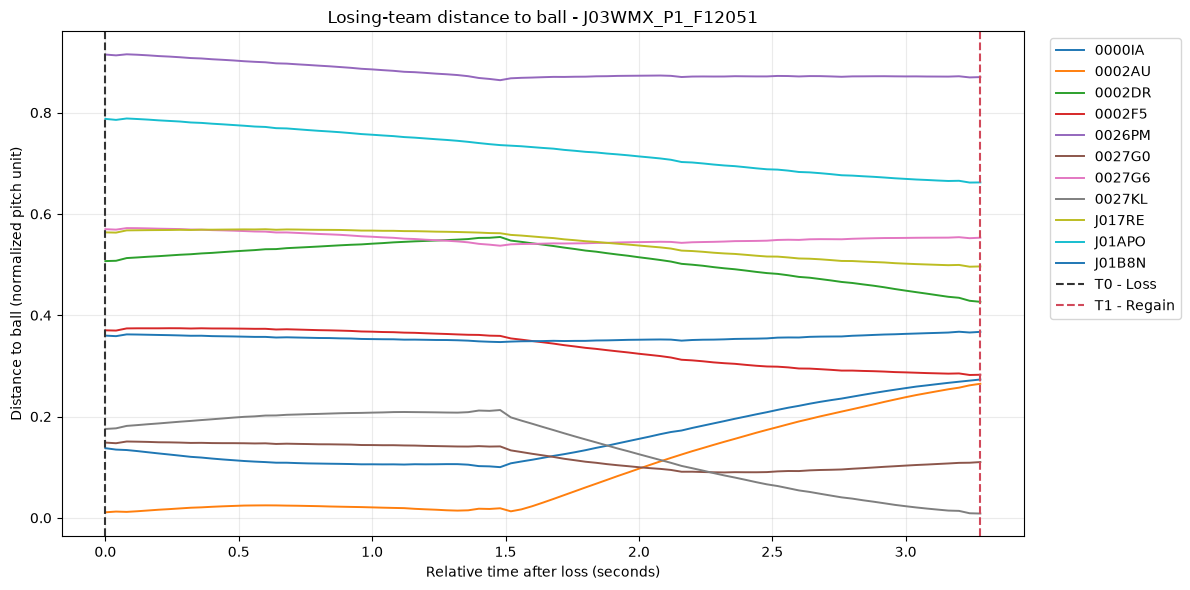

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
for player_id, group in post_loss_ts.groupby('player_id'):
    ax.plot(
        group['relative_time'],
        group['distance_to_ball'],
        linewidth=1.4,
        label=player_id.replace('DFL-OBJ-', ''),
    )
ax.axvline(0, color='#333333', linestyle='--', label='T0 - Loss')
ax.axvline(
    float(episode['regain_gap_seconds']),
    color='#D1495B', linestyle='--', label='T1 - Regain',
)
ax.set(
    xlabel='Relative time after loss (seconds)',
    ylabel='Distance to ball (normalized pitch unit)',
    title=f"Losing-team distance to ball - {episode['candidate_id']}",
)
ax.grid(alpha=0.25)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
plt.show()